<a href="https://colab.research.google.com/github/fathimapb/ML-DL_Projects/blob/main/Student_Performance/StudentPerformancePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**AI Based Student Performance Prediction System**

Problem statement
Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance using historical academic and behavioural data to support timely intervention.

Objective
To build a machine learning model that predicts whether a student will perform well or poorly based on multiple factors and provide insights for improvement.

Dataset
Student academic dataset containing
Attendance percentage
Internal assessment marks
Previous semester grades
Study hours
Participation in activities
Socio economic indicators
You can use a public dataset or create a realistic one.

Technologies used
Python
Pandas
NumPy
Matplotlib and Seaborn
Scikit learn
Jupyter Notebook.

Workflow
1 Data understanding and problem definition
2 Data cleaning and handling missing values
3 Exploratory data analysis
4 Feature selection and encoding
5 Train test split
6 Model building using Logistic Regression Random Forest
7 Model evaluation using accuracy precision recall and confusion matrix
8 Result interpretation and insights
9 Conclusion and future scope.

Output
Prediction of student performance category
Important features influencing performance
Visual dashboards showing trends


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/student_performance_dataset.csv")
df



,attendance_percentage,internal_marks,previous_grade,study_hours_per_week,participation_level,socio_economic_status,performance
0,82.450712,85.611892,B,23.412105,Medium,Low,Good
1,72.926035,41.892905,D,2.744037,Medium,High,Good
2,84.715328,76.508744,F,11.602008,Medium,Low,Poor
3,97.845448,52.615231,F,21.007386,Medium,Middle,Poor
4,71.487699,58.451944,B,14.155085,Low,Low,Good
...,...,...,...,...,...,...,...
99995,71.621626,39.709035,B,8.072041,Medium,Middle,Poor
99996,66.453337,76.313083,C,11.814007,Low,Low,Poor
99997,81.137776,68.200399,B,5.583781,Medium,Middle,Poor
99998,71.833625,82.113462,D,5.168229,Medium,Low,Poor


In [ ]:
df.head()

,attendance_percentage,internal_marks,previous_grade,study_hours_per_week,participation_level,socio_economic_status,performance
0,82.450712,85.611892,B,23.412105,Medium,Low,Good
1,72.926035,41.892905,D,2.744037,Medium,High,Good
2,84.715328,76.508744,F,11.602008,Medium,Low,Poor
3,97.845448,52.615231,F,21.007386,Medium,Middle,Poor
4,71.487699,58.451944,B,14.155085,Low,Low,Good


In [ ]:
df.tail()

,attendance_percentage,internal_marks,previous_grade,study_hours_per_week,participation_level,socio_economic_status,performance
99995,71.621626,39.709035,B,8.072041,Medium,Middle,Poor
99996,66.453337,76.313083,C,11.814007,Low,Low,Poor
99997,81.137776,68.200399,B,5.583781,Medium,Middle,Poor
99998,71.833625,82.113462,D,5.168229,Medium,Low,Poor
99999,76.800944,43.701041,F,8.384545,High,High,Poor


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   attendance_percentage  100000 non-null  float64
 1   internal_marks         100000 non-null  float64
 2   previous_grade         100000 non-null  object 
 3   study_hours_per_week   100000 non-null  float64
 4   participation_level    100000 non-null  object 
 5   socio_economic_status  100000 non-null  object 
 6   performance            100000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 5.3+ MB


In [ ]:
df.isnull().sum()

,0
attendance_percentage,0
internal_marks,0
previous_grade,0
study_hours_per_week,0
participation_level,0
socio_economic_status,0
performance,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.shape

(100000, 7)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(99999, 7)

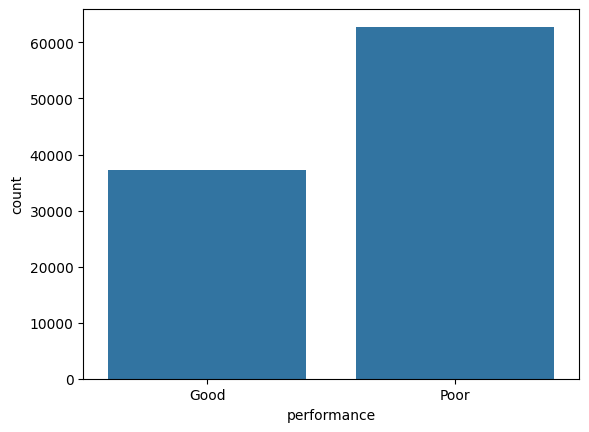

In [ ]:
sns.countplot(x='performance', data=df)
plt.show()

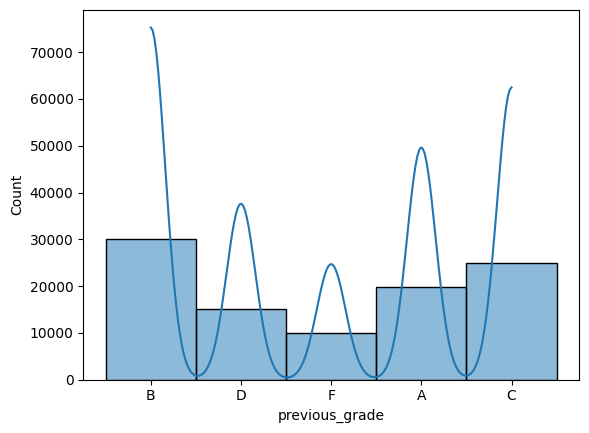

In [ ]:
sns.histplot(df['previous_grade'], kde=True)
plt.show()

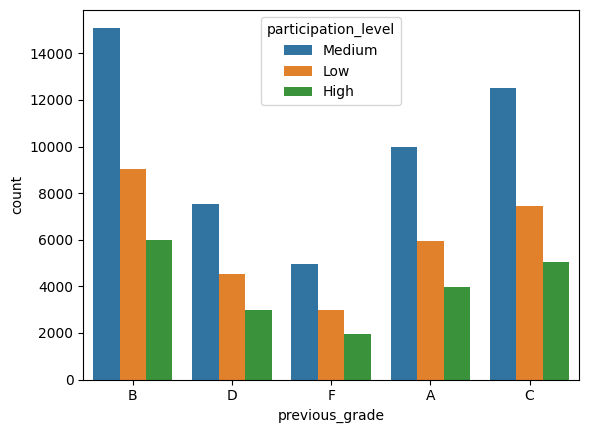

In [ ]:
sns.countplot(data=df, x='previous_grade', hue='participation_level')
plt.show()

In [ ]:
df.head()

,attendance_percentage,internal_marks,previous_grade,study_hours_per_week,participation_level,socio_economic_status,performance
0,82.450712,85.611892,B,23.412105,Medium,Low,Good
1,72.926035,41.892905,D,2.744037,Medium,High,Good
2,84.715328,76.508744,F,11.602008,Medium,Low,Poor
3,97.845448,52.615231,F,21.007386,Medium,Middle,Poor
4,71.487699,58.451944,B,14.155085,Low,Low,Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99999 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   attendance_percentage  99999 non-null  float64
 1   internal_marks         99999 non-null  float64
 2   previous_grade         99999 non-null  object 
 3   study_hours_per_week   99999 non-null  float64
 4   participation_level    99999 non-null  object 
 5   socio_economic_status  99999 non-null  object 
 6   performance            99999 non-null  object 
dtypes: float64(3), object(4)
memory usage: 6.1+ MB


In [ ]:
# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()

# df['previous_grade'] = le.fit_transform(df['previous_grade'])
# df['participation_level'] = le.fit_transform(df['participation_level'])
# df['socio_economic_status'] = le.fit_transform(df['socio_economic_status'])
# df['performance'] = le.fit_transform(df['performance'])

In [ ]:
print(df["socio_economic_status"].unique())

['Low' 'High' 'Middle']


In [ ]:
df["previous_grade"].replace(['F', 'D', 'C', 'B', 'A'],[1,2,3,4,5],inplace=True)

/tmp/ipykernel_4529/2148124196.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["previous_grade"].replace(['F', 'D', 'C', 'B', 'A'],[1,2,3,4,5],inplace=True)
/tmp/ipykernel_4529/2148124196.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["previous_grade"].replace(['F', 'D', 'C', 'B', 'A'

In [ ]:
df["participation_level"].replace(['Low', 'Medium', 'High'],[1,2,3],inplace=True)

/tmp/ipykernel_4529/1781471991.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["participation_level"].replace(['Low', 'Medium', 'High'],[1,2,3],inplace=True)
/tmp/ipykernel_4529/1781471991.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["participation_level"].replace(['Low', 'Medium', 

In [ ]:
df["socio_economic_status"].replace(['Low', 'Middle', 'High'],[1,2,3],inplace=True)

/tmp/ipykernel_4529/2009692573.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["socio_economic_status"].replace(['Low', 'Middle', 'High'],[1,2,3],inplace=True)
/tmp/ipykernel_4529/2009692573.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["socio_economic_status"].replace(['Low', 'Middl

In [ ]:
df['performance'] = df['performance'].map({'Poor': 0, 'Good': 1})

In [ ]:
df

,attendance_percentage,internal_marks,previous_grade,study_hours_per_week,participation_level,socio_economic_status,performance
0,82.450712,85.611892,4,23.412105,2,1,1
1,72.926035,41.892905,2,2.744037,2,3,1
2,84.715328,76.508744,1,11.602008,2,1,0
3,97.845448,52.615231,1,21.007386,2,2,0
4,71.487699,58.451944,4,14.155085,1,1,1
...,...,...,...,...,...,...,...
99995,71.621626,39.709035,4,8.072041,2,2,0
99996,66.453337,76.313083,3,11.814007,1,1,0
99997,81.137776,68.200399,4,5.583781,2,2,0
99998,71.833625,82.113462,2,5.168229,2,1,0


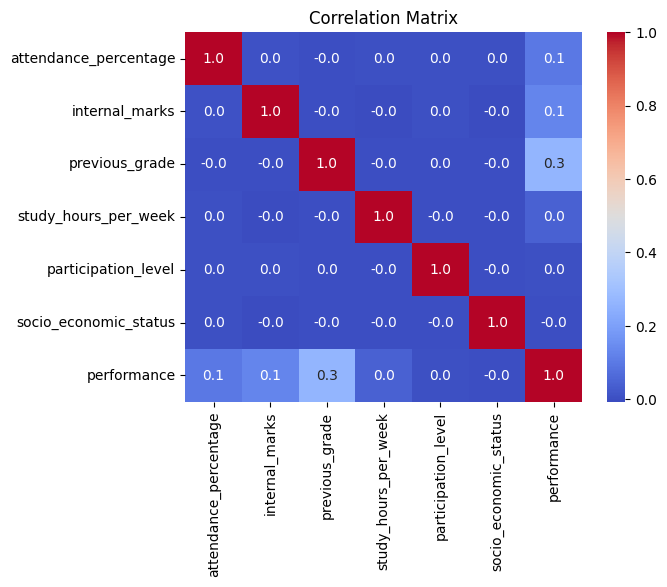

In [ ]:
corr_matrix = df.corr()

sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

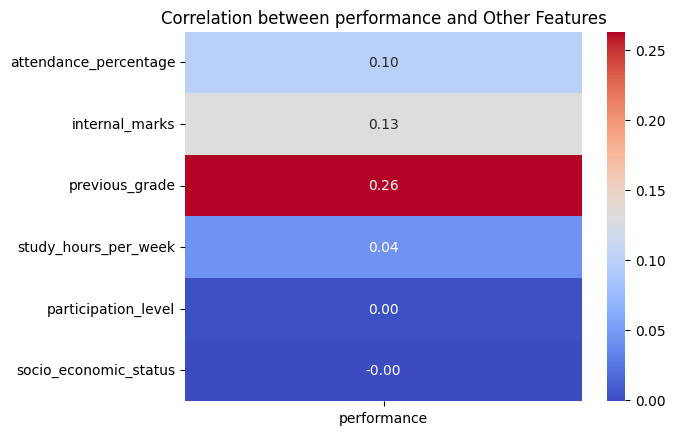

In [ ]:
survived_corr = df.corr()['performance']

survived_corr = survived_corr.drop('performance')

sns.heatmap(survived_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between performance and Other Features')
plt.show()

In [ ]:
df.drop(['study_hours_per_week','participation_level','socio_economic_status'],axis=1,inplace=True)

<Axes: >

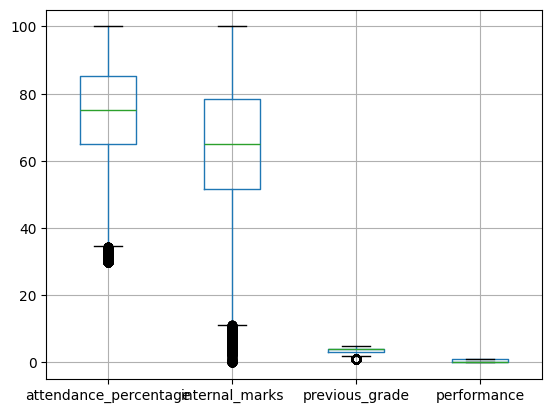

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:
        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

df_cleaned = remove_outliers_iqr(df, exclude_column='performance')
df=df_cleaned

In [ ]:
df.shape

(89476, 4)

In [ ]:
df.head()

,attendance_percentage,internal_marks,previous_grade,performance
0,82.450712,85.611892,4,1
1,72.926035,41.892905,2,1
4,71.487699,58.451944,4,1
5,71.487946,65.952085,4,0
6,98.688192,62.610179,5,1


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



features = ['attendance_percentage', 'internal_marks', 'previous_grade']

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd



X = df[['attendance_percentage', 'internal_marks', 'previous_grade']]
y = df['performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd



X = df[['attendance_percentage', 'internal_marks', 'previous_grade']]
y = df['performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model =DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.55


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd




X = df[['attendance_percentage', 'internal_marks', 'previous_grade']]
y = df['performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model=SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


X = df[['attendance_percentage', 'internal_marks', 'previous_grade']]
y = df['performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model=RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')



Baseline model accuracy: 0.59


##KFold


In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

In [ ]:
X=df.drop('performance',axis=1)
y=df['performance']

# Kfold setup
kf=KFold(n_splits=5,shuffle=True,random_state=42)
model=LogisticRegression(max_iter=1000) # Increased max_iter to address ConvergenceWarning
# Track best fold data
best_accuracy=0
best_fold=1

# Save best fold's data
best_X_train=None
best_y_train=None
best_X_test=None
best_y_test=None
best_y_pred=None

# Loop over each fold
for fold,(train_index,test_index) in enumerate(kf.split(X),1):
  X_train,X_test=X.iloc[train_index],X.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]

  # Train model
  model.fit(X_train,y_train)

  # Predict
  y_pred=model.predict(X_test)
  acc=accuracy_score(y_test,y_pred)
  print(f"Fold {fold} Accuracy: {acc:.2f}")

  # Update best fold
  if acc > best_accuracy:
    best_accuracy=acc
    best_fold=fold
    best_X_train=X_train
    best_y_train=y_train
    best_X_test=X_test
    best_y_test=y_test
    best_y_pred=y_pred

# Output best fold details
print(f"\nBest Fold:{best_fold} with accuracy:{best_accuracy:.2f}")

Fold 1 Accuracy: 0.64
Fold 2 Accuracy: 0.65
Fold 3 Accuracy: 0.65
Fold 4 Accuracy: 0.64
Fold 5 Accuracy: 0.64

Best Fold:2 with accuracy:0.65


In [ ]:
model=LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.6485051690416317

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.5592623637887678

In [ ]:
from sklearn.svm import SVC
model=SVC()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.6330818664431406

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.5965912265996088

In [ ]:
from keras import preprocessing
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification



In [ ]:
model=Sequential()
model.add(Dense(128,input_shape=(3,),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train,y_train,epochs=80,batch_size=32)

Epoch 1/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5946 - loss: 0.6761
Epoch 2/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6157 - loss: 0.6536
Epoch 3/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6271 - loss: 0.6444
Epoch 4/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6321 - loss: 0.6394
Epoch 5/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6351 - loss: 0.6368
Epoch 6/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6342 - loss: 0.6369
Epoch 7/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6393 - loss: 0.6352
Epoch 8/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6369 - loss: 0.6356
Epoch 9/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6391 - loss: 0.6344
Epoch 10/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6380 - loss: 0.6347
Epoch 11/80
2237/2237 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6385 - loss: 0.6342
Epoch 12/80
2237/2237 ━━━━━━━━

In [ ]:
probs=model.predict(np.expand_dims(X_test.iloc[0],axis=0))

pred_classes=np.round(probs).astype(int)

print("Probabilities:\n",probs.flatten())
print()
print("Predicted classes (by rounding):",pred_classes.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Probabilities:
 [0.39163008]

Predicted classes (by rounding): [0]


In [ ]:
loss,accuracy=model.evaluate(X_test,y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6430 - loss: 0.6318
Model Accuracy: 64.30%


**Conclusion**

The AI-Based Student Performance Prediction System was successfully developed using machine learning techniques to classify student performance as Good or Poor. The model was trained on academic and behavioral features such as attendance, internal marks, previous grades, study hours, participation level, and socio-economic status.

Among the models tested, Logistic Regression performed the best, achieving an accuracy of 64.85%. This indicates that the model is able to capture some underlying patterns in student performance, but its predictive capability is moderate rather than highly reliable.

The results suggest that:

 -Academic indicators like internal marks and previous grades play a significant role in predicting performance.
 -Behavioral factors such as study hours and participation also contribute meaningfully.
 -However, the current feature set and model may not fully capture the complexity of student performance.

The model can still be useful for early identification of at-risk students, allowing educators to take timely interventions. However, it should not be used as the sole decision-making tool due to its limited accuracy.

Insights

 -Performance prediction is influenced by multiple interacting factors, not a single variable
 -Linear models like Logistic Regression may miss complex relationships
 -Data quality and feature richness directly impact model performance

Future Scope

To improve the system:

 -Include additional features such as:
   -Sleep patterns
   -Stress levels
   -Attendance consistency over time
 -Try advanced models:
   -Random Forest (tuned)
   -Gradient Boosting (XGBoost, LightGBM)
 -Perform hyperparameter tuning
 -Handle class imbalance (if present)
 -Use feature engineering (e.g., combined performance scores)
 -Apply cross-validation for more reliable evaluation

Final Verdict

The project demonstrates that machine learning can assist in predicting student performance, but achieving high accuracy requires better features, tuning, and possibly more advanced models.